# Fundamental Factor Analysis

Four economic logic factors: **Size**, **Book-to-Market (B/M)**, **ROA**, **Abnormal Turnover**

Universe: CSI 300 constituents | Period: 2016-2025 | Frequency: Monthly

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({"figure.figsize": (16, 4), "axes.grid": True, "grid.alpha": 0.3})

In [3]:
monthly  = pd.read_parquet("data/monthly_data.parquet")
balance  = pd.read_parquet("data/balance.parquet")
income   = pd.read_parquet("data/income.parquet")
capital  = pd.read_parquet("data/capital.parquet")
etf300   = pd.read_parquet("data/ref_data/ETF_hold_510300.SH.parquet")
industry = pd.read_parquet("data/ref_data/Stock_Industry_Year.parquet")

for df in [monthly, balance, income, capital, etf300, industry]:
    df["stock_code"] = df["stock_code"].astype(str)

print("monthly:", monthly.shape, "| balance:", balance.shape,
      "| income:", income.shape, "| capital:", capital.shape,
      "| etf300:", etf300.shape, "| industry:", industry.shape)

monthly: (598593, 6) | balance: (336609, 15) | income: (515192, 17) | capital: (129315, 6) | etf300: (3297, 6) | industry: (56951, 3)


## Base Panel Construction

Forward-fill semi-annual ETF holdings to monthly universe, attach market cap, compute next-period return.

In [5]:
# CSI 300 universe: forward-fill semi-annual ETF holdings to monthly
etf300["end_date"] = pd.to_datetime(etf300["end_date"])
all_months = pd.date_range("2015-12-31", "2025-12-31", freq="ME")  # early start for vol warm-up

rows = []
for m in all_months:
    valid = etf300[etf300["end_date"] <= m]
    if valid.empty:
        continue
    latest = valid["end_date"].max()
    if (m - latest).days > 185:
        continue
    for s in valid[valid["end_date"] == latest]["stock_code"].values:
        rows.append((m, s))
universe_df = pd.DataFrame(rows, columns=["month_end", "stock_code"])
print(f"Universe rows: {universe_df.shape}")

Universe rows: (14700, 2)


In [6]:
# Market cap: point-in-time merge of total_shares from capital
# Use left-merge + filter instead of merge_asof (pandas 1.3 compatibility)
capital["change_date"] = pd.to_datetime(
    capital["change_date"].astype(str), format="%Y%m%d", errors="coerce")
cap_clean = capital.dropna(subset=["change_date"])[["stock_code", "change_date", "total_shares"]]

# Cross-join monthly with capital, keep change_date <= month_end, take latest per group
tmp = monthly.merge(cap_clean, on="stock_code", how="left")
tmp = tmp[tmp["change_date"] <= tmp["month_end"]]
tmp = (tmp.sort_values("change_date")
          .groupby(["stock_code", "month_end"])["total_shares"].last().reset_index())
panel = monthly.merge(tmp, on=["stock_code", "month_end"], how="left")
panel["mktcap"] = panel["adjusted_close"].astype(float) * panel["total_shares"]

# Filter to study period and CSI 300 universe
panel = panel[(panel["month_end"] >= "2016-01-01") & (panel["month_end"] <= "2025-12-31")]
panel = panel.merge(universe_df, on=["month_end", "stock_code"], how="inner")

# Next-period return: factor at t predicts return at t+1
panel = panel.sort_values(["stock_code", "month_end"])
panel["next_return"] = panel.groupby("stock_code")["monthly_return"].shift(-1)

avg_n = panel.groupby("month_end").size().mean()
print(f"Base panel: {panel.shape}  |  Avg stocks/month: {avg_n:.0f}")
panel.head(3)

Base panel: (9896, 9)  |  Avg stocks/month: 300


,stock_code,month_end,close_price,adjusted_close,monthly_volume,monthly_return,total_shares,mktcap,next_return
0,000001.SZ,2021-12-31,16.4800,1132.2209,25604471.9700,-0.0658,1940254.1413,2196796381.7576,-0.0390
1,000001.SZ,2022-02-28,15.7500,1082.0680,16279521.5300,-0.0390,1940254.1413,2099486904.8655,-0.0339
2,000001.SZ,2022-03-31,15.3800,1056.6479,27991481.4500,-0.0339,1940254.1413,2050165559.3295,-0.0757


## Helper Functions

In [7]:
def pit_merge(fin_df, base_df, value_cols):
    """Point-in-time merge: attach latest announced financials to each (stock, month_end).
    Uses left-merge + filter to avoid merge_asof pandas 1.3 sort requirement.
    """
    fin = fin_df.copy()
    fin["announce_date"] = pd.to_datetime(
        fin["announce_date"].astype(str), format="%Y%m%d", errors="coerce")
    if "statement_type" in fin.columns:
        fin = fin[fin["statement_type"].isin(["ORIGINAL", "RESTATED"])]
    fin = (fin.dropna(subset=["announce_date"])
              .groupby(["stock_code", "announce_date"])[value_cols]
              .last().reset_index())
    base = base_df[["stock_code", "month_end"]].drop_duplicates()
    tmp = base.merge(fin, on="stock_code", how="left")
    tmp = tmp[tmp["announce_date"] <= tmp["month_end"]]
    tmp = (tmp.sort_values("announce_date")
              .groupby(["stock_code", "month_end"])[value_cols]
              .last().reset_index())
    return base.merge(tmp, on=["stock_code", "month_end"], how="left")


def decile_sort(df, factor_col, n=10):
    """Assign decile ranks (1=low, 10=high) cross-sectionally each month."""
    out = []
    for _, g in df.groupby("month_end"):
        g = g.dropna(subset=[factor_col, "next_return"]).copy()
        if len(g) < n * 3:
            continue
        g["decile"] = pd.qcut(g[factor_col], n, labels=False) + 1
        out.append(g)
    return pd.concat(out, ignore_index=True)


def portfolio_table(dec_df, return_col="next_return", n=10):
    """Decile summary: Ann. EW/VW return, volatility, avg market cap."""
    rows = []
    for d in range(1, n + 1):
        g = dec_df[dec_df["decile"] == d]
        ew_m = g.groupby("month_end")[return_col].mean()
        vw_m = g.groupby("month_end").apply(
            lambda x: (x["mktcap"] / x["mktcap"].sum() * x[return_col]).sum())
        rows.append({
            "Decile": f"P{d}" + (" (Low)" if d == 1 else " (High)" if d == n else ""),
            "EW Return (ann.)": ew_m.mean() * 12,
            "VW Return (ann.)": vw_m.mean() * 12,
            "EW Vol (ann.)":    ew_m.std()  * (12 ** 0.5),
            "Avg Mkt Cap (B CNY)": g["mktcap"].mean() / 1e9,
        })
    tbl = pd.DataFrame(rows).set_index("Decile")
    return tbl.style.format({
        "EW Return (ann.)": "{:.2%}",
        "VW Return (ann.)": "{:.2%}",
        "EW Vol (ann.)":    "{:.2%}",
        "Avg Mkt Cap (B CNY)": "{:.1f}",
    })


def ls_returns(dec_df, return_col="next_return", n=10, long_high=True):
    """Monthly long-short returns (equal-weight).
    long_high=True  → Long P10, Short P1 (B/M, ROA)
    long_high=False → Long P1,  Short P10 (Size, Abnormal Turnover)
    """
    long_d, short_d = (n, 1) if long_high else (1, n)
    rows = []
    for date, g in dec_df.groupby("month_end"):
        long  = g[g["decile"] == long_d][return_col].mean()
        short = g[g["decile"] == short_d][return_col].mean()
        rows.append({"month_end": date, "ls": long - short,
                     "long": long, "short": short})
    return pd.DataFrame(rows).set_index("month_end")


def rank_ic(df, factor_col, return_col="next_return", direction=1):
    """Monthly cross-sectional Spearman rank IC.
    direction=1  : higher factor → higher return (B/M, ROA)
    direction=-1 : higher factor → lower  return (Size, Abnormal Turnover)
    Multiplying by direction ensures positive IC always means the factor works.
    """
    ics = []
    for date, g in df.groupby("month_end"):
        g = g.dropna(subset=[factor_col, return_col])
        if len(g) < 10:
            continue
        ic, _ = stats.spearmanr(g[factor_col], g[return_col])
        ics.append({"month_end": date, "IC": ic * direction})
    return pd.DataFrame(ics).set_index("month_end")["IC"]


def ic_summary(ic_s, ls_df, long_high=True):
    """IC + L/S return statistics table."""
    mean_ic = ic_s.mean()
    icir    = mean_ic / ic_s.std() * (12 ** 0.5)
    long_label  = "Long-leg P10 (ann.)" if long_high else "Long-leg P1  (ann.)"
    short_label = "Short-leg P1  (ann.)" if long_high else "Short-leg P10 (ann.)"
    return pd.DataFrame({"Value": [
        f"{mean_ic:.4f}",
        f"{icir:.2f}",
        f"{(ic_s > 0).mean():.1%}",
        f"{ls_df['ls'].mean() * 12:.2%}",
        f"{ls_df['long'].mean() * 12:.2%}",
        f"{ls_df['short'].mean() * 12:.2%}",
        f"{(ls_df['ls'] > 0).mean():.1%}",
    ]}, index=[
        "Mean Rank IC (monthly)", "ICIR (annualized)", "IC Win Rate",
        "L/S Return (ann.)", long_label, short_label, "L/S Win Rate",
    ])


def plot_factor(name, dec_df, ls_df, return_col="next_return", n=10, long_high=True, save=None):
    """2-panel: decile EW returns bar | cumulative L/S returns."""
    long_label  = f"Long  (P{n})" if long_high else "Long  (P1)"
    short_label = "Short (P1)"    if long_high else f"Short (P{n})"
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # --- Decile bar ---
    ew = [dec_df[dec_df["decile"] == d].groupby("month_end")[return_col]
          .mean().mean() * 12 for d in range(1, n + 1)]
    # long_high=True: P10 is long (blue), P1 is short (red)
    # long_high=False: P1 is long (blue), P10 is short (red)
    colors = [("#4575b4" if i == 0 else "#d73027" if i == n - 1 else "#aaaaaa")
              if not long_high
              else ("#d73027" if i == 0 else "#4575b4" if i == n - 1 else "#aaaaaa")
              for i in range(n)]
    axes[0].bar(range(1, n + 1), ew, color=colors)
    axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    axes[0].set_xlabel("Decile (1=Low, 10=High)")
    axes[0].set_title("Decile EW Returns (Ann.)")

    # --- Cumulative L/S ---
    (1 + ls_df["ls"]).cumprod().plot(
        ax=axes[1], color="black",   label="L/S",        lw=1.5)
    (1 + ls_df["long"]).cumprod().plot(
        ax=axes[1], color="#4575b4", label=long_label,   alpha=0.7)
    (1 + ls_df["short"]).cumprod().plot(
        ax=axes[1], color="#d73027", label=short_label,  alpha=0.7)
    axes[1].axhline(1, color="gray", lw=0.5)
    axes[1].set_title("Cumulative L/S Return")
    axes[1].legend(fontsize=8)

    fig.suptitle(name, fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save:
        fig.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()


def plot_ic_summary(ic_s, ls_df, long_high=True, save=None):
    """Rank IC bar (green/red) + cumulative IC (right axis) beside the summary table."""
    fig = plt.figure(figsize=(14, 4))
    gs  = fig.add_gridspec(1, 2, width_ratios=[2, 1])
    ax_ic  = fig.add_subplot(gs[0])
    ax_tbl = fig.add_subplot(gs[1])

    # --- IC bar ---
    bar_colors = ["#2ca02c" if v >= 0 else "#d62728" for v in ic_s.values]
    ax_ic.bar(ic_s.index, ic_s.values, color=bar_colors, alpha=0.65, width=20, label="Rank IC")
    ax_ic.axhline(0, color="black", lw=0.5)
    ax_ic.set_title("Rank IC")
    ax_ic.set_ylabel("Rank IC")

    # --- Cumulative IC (right axis) ---
    ax_r = ax_ic.twinx()
    ic_s.cumsum().plot(ax=ax_r, color="#2166ac", lw=1.8, label="Cumulative IC")
    ax_r.set_ylabel("Cumulative IC", color="#2166ac")
    ax_r.tick_params(axis="y", labelcolor="#2166ac")
    h1, l1 = ax_ic.get_legend_handles_labels()
    h2, l2 = ax_r.get_legend_handles_labels()
    ax_ic.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")

    # --- Summary table ---
    summ = ic_summary(ic_s, ls_df, long_high=long_high)
    tbl_data = [[idx, val] for idx, val in zip(summ.index, summ["Value"])]
    ax_tbl.axis("off")
    tbl = ax_tbl.table(
        cellText=tbl_data,
        colLabels=["Metric", "Value"],
        cellLoc="left", loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.3, 1.6)
    ax_tbl.set_title("IC Summary", fontweight="bold", pad=12)

    plt.tight_layout()
    if save:
        fig.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()


import os
os.makedirs("figures", exist_ok=True)
print("Helper functions loaded. figures/ directory ready.")

Helper functions loaded. figures/ directory ready.


---
## Factor 1: Size

**Definition:** `log(market_cap)` where `market_cap = adjusted_close × total_shares`

Small-cap premium (Banz 1981): P1 (small) expected to outperform P10 (large). Factor is negatively signed.

In [8]:
size_panel = panel.dropna(subset=["mktcap", "next_return"]).copy()
size_panel = size_panel[size_panel["mktcap"] > 0]
size_panel["size"] = np.log(size_panel["mktcap"])

dec_size = decile_sort(size_panel, "size")
ic_size  = rank_ic(size_panel, "size", direction=-1)  # larger size → lower return
ls_size  = ls_returns(dec_size, long_high=False)  # Long small-cap (P1), Short large-cap (P10)
print(f"Size: {dec_size.shape[0]:,} stock-month obs across {dec_size['month_end'].nunique()} months")

Size: 9,374 stock-month obs across 32 months


In [10]:
portfolio_table(dec_size)

,EW Return (ann.),VW Return (ann.),EW Vol (ann.),Avg Mkt Cap (B CNY)
Decile,,,,
P1 (Low),10.03%,10.49%,30.33%,0.0
P2,7.20%,7.08%,22.56%,0.0
P3,5.75%,6.50%,23.14%,0.0
P4,6.84%,6.91%,22.30%,0.0
P5,3.29%,3.65%,21.90%,0.0
P6,13.84%,14.05%,24.58%,0.0
P7,2.88%,3.29%,22.98%,0.1
P8,5.91%,6.30%,24.94%,0.1
P9,5.26%,4.20%,18.61%,0.3


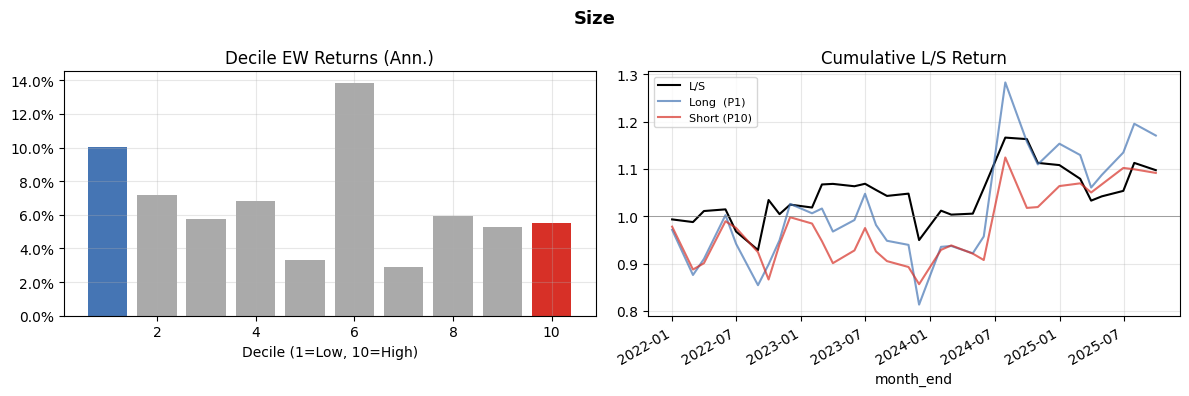

In [11]:
plot_factor("Size", dec_size, ls_size, long_high=False, save="figures/Size_return.png")

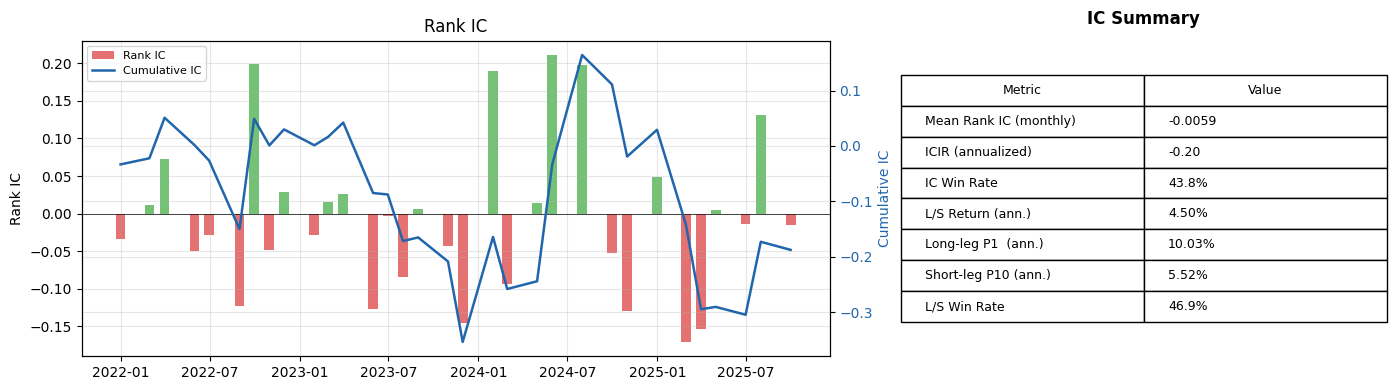

In [12]:
plot_ic_summary(ic_size, ls_size, long_high=False, save="figures/Size_ic.png")

---
## Factor 2: Book-to-Market (B/M)

**Definition:** `equity_parent / market_cap`

Value premium: high B/M stocks tend to outperform. Financial data merged point-in-time via `announce_date` to prevent look-ahead bias.

In [13]:
# Point-in-time merge of equity_parent from balance sheet
bm_fin = pit_merge(
    balance[["stock_code", "announce_date", "statement_type", "equity_parent"]],
    panel[["stock_code", "month_end"]],
    ["equity_parent"]
)
bm_panel = panel.merge(
    bm_fin[["stock_code", "month_end", "equity_parent"]],
    on=["stock_code", "month_end"], how="left"
)
bm_panel["bm"] = bm_panel["equity_parent"] / bm_panel["mktcap"]

# Remove negative equity and extreme outliers (top 1%)
bm_panel = bm_panel[(bm_panel["bm"] > 0) &
                     (bm_panel["bm"] < bm_panel["bm"].quantile(0.99))]

dec_bm = decile_sort(bm_panel, "bm")
ic_bm  = rank_ic(bm_panel, "bm")
ls_bm  = ls_returns(dec_bm)
print(f"B/M: {dec_bm.shape[0]:,} obs | coverage: {bm_panel['bm'].notna().mean():.1%}")

B/M: 9,279 obs | coverage: 100.0%


In [14]:
portfolio_table(dec_bm)

,EW Return (ann.),VW Return (ann.),EW Vol (ann.),Avg Mkt Cap (B CNY)
Decile,,,,
P1 (Low),3.48%,2.22%,26.32%,0.9
P2,7.45%,6.27%,26.22%,0.3
P3,7.79%,4.20%,27.84%,0.2
P4,2.20%,-0.24%,24.41%,0.1
P5,-1.46%,-1.22%,28.20%,0.1
P6,8.58%,10.44%,25.95%,0.1
P7,4.29%,7.57%,22.14%,0.1
P8,8.94%,7.78%,20.81%,0.0
P9,9.08%,11.87%,18.21%,0.0


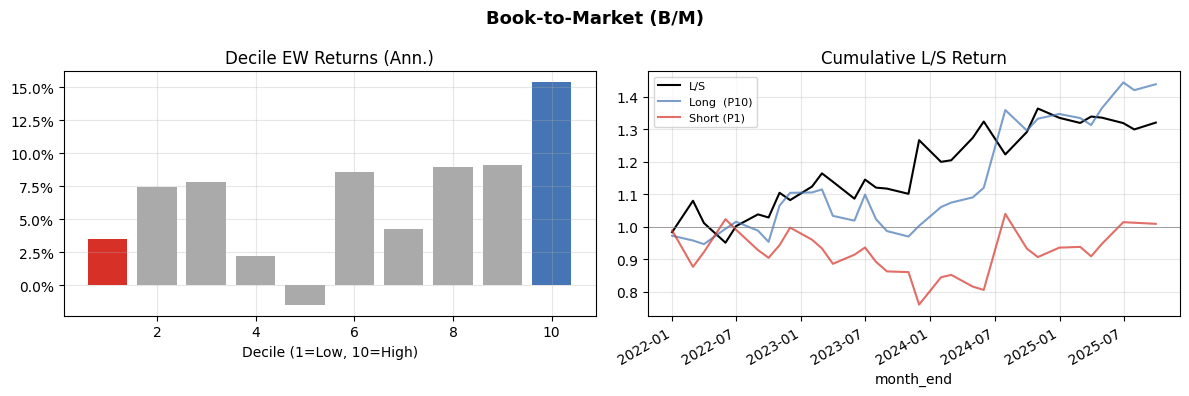

In [15]:
plot_factor("Book-to-Market (B/M)", dec_bm, ls_bm, save="figures/BM_return.png")

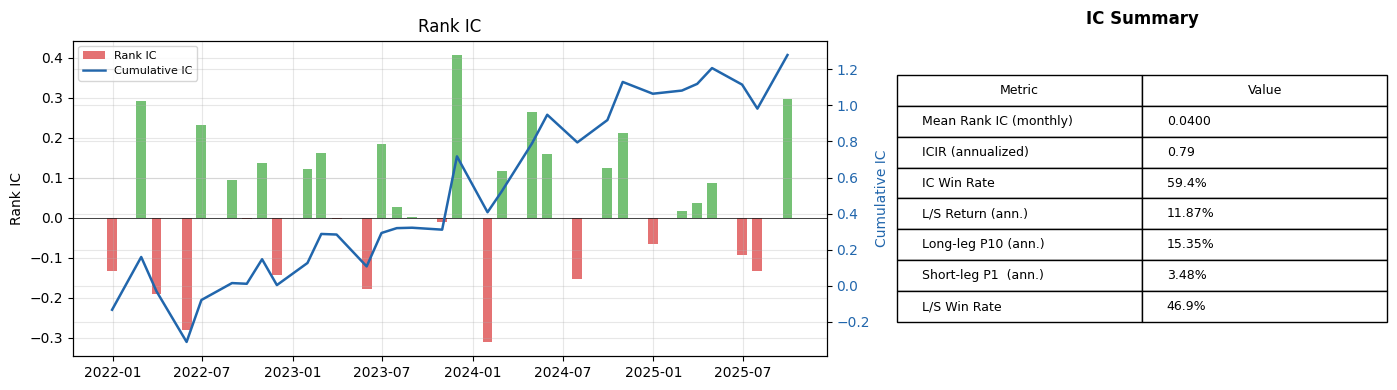

In [16]:
plot_ic_summary(ic_bm, ls_bm, save="figures/BM_ic.png")

---
## Factor 3: Return on Assets (ROA)

**Definition:** `net_profit_parent / total_assets` (annualized), industry-neutralized

Profitable firms tend to outperform (Fama-French RMW factor). Income and balance data are joined on the same `report_period`, then the later `announce_date` is used for point-in-time correctness. ROA is neutralized within SW Level-1 industry each month to remove sector composition bias (e.g. banks have structurally low ROA but stable returns, distorting raw decile sorts).

In [17]:
# Convert category columns to str first — category sort order != chronological order
def prep_fin(df, value_col):
    return (df[df["statement_type"].isin(["ORIGINAL", "RESTATED"])]
            .assign(
                stock_code    = lambda x: x["stock_code"].astype(str),
                report_period = lambda x: x["report_period"].astype(str),
                announce_date = lambda x: x["announce_date"].astype(str),
            )
            .sort_values("announce_date")
            .groupby(["stock_code", "report_period"])
            [["announce_date", value_col]].last().reset_index())

inc_best = prep_fin(income,  "net_profit_parent")
bal_best = prep_fin(balance, "total_assets")

fin_roa = inc_best.merge(bal_best, on=["stock_code", "report_period"],
                          suffixes=("_inc", "_bal"))
# Use the later of the two announce dates
fin_roa["announce_date"] = fin_roa[["announce_date_inc", "announce_date_bal"]].max(axis=1)

# Annualise net_profit: YTD months varies by quarter (Q1=3, Q2=6, Q3=9, Q4=12)
_month_map = {"0331": 3, "0630": 6, "0930": 9, "1231": 12}
fin_roa["_months"] = fin_roa["report_period"].str[-4:].map(_month_map)
fin_roa["net_profit_ann"] = fin_roa["net_profit_parent"] * 12 / fin_roa["_months"]
fin_roa["roa"] = fin_roa["net_profit_ann"] / fin_roa["total_assets"]
fin_roa = fin_roa[["stock_code", "announce_date", "roa"]].dropna()

# Point-in-time merge via left-merge + filter
fin_roa["announce_dt"] = pd.to_datetime(
    fin_roa["announce_date"], format="%Y%m%d", errors="coerce")
fin_roa = fin_roa.dropna(subset=["announce_dt", "roa"])

base = panel[["stock_code", "month_end"]].drop_duplicates()
roa_tmp = base.merge(fin_roa[["stock_code", "announce_dt", "roa"]], on="stock_code", how="left")
roa_tmp = roa_tmp[roa_tmp["announce_dt"] <= roa_tmp["month_end"]]
roa_pit = (roa_tmp.sort_values("announce_dt")
           .groupby(["stock_code", "month_end"])["roa"].last().reset_index())
roa_panel = panel.merge(roa_pit, on=["stock_code", "month_end"], how="left")
roa_panel = roa_panel.dropna(subset=["roa", "next_return"])

# Industry neutralization: subtract cross-sectional industry mean each month
# Removes sector composition bias (e.g. banks have low ROA but stable returns)
roa_panel["year"] = roa_panel["month_end"].dt.year
roa_panel = roa_panel.merge(
    industry[["stock_code", "year", "industry_name"]],
    on=["stock_code", "year"], how="left"
)
roa_panel["roa_neutral"] = (
    roa_panel.groupby(["month_end", "industry_name"])["roa"]
    .transform(lambda x: x - x.mean())
)
# Fall back to raw roa for stocks with missing industry
roa_panel["roa_neutral"] = roa_panel["roa_neutral"].fillna(roa_panel["roa"])

dec_roa = decile_sort(roa_panel, "roa_neutral")
ic_roa  = rank_ic(roa_panel, "roa_neutral")
ls_roa  = ls_returns(dec_roa)
print(f"ROA: {dec_roa.shape[0]:,} obs | coverage: {roa_panel['roa_neutral'].notna().mean():.1%}")

ROA: 9,502 obs | coverage: 100.0%


In [18]:
portfolio_table(dec_roa)

,EW Return (ann.),VW Return (ann.),EW Vol (ann.),Avg Mkt Cap (B CNY)
Decile,,,,
P1 (Low),4.20%,4.22%,24.77%,0.1
P2,4.42%,0.96%,21.43%,0.1
P3,11.51%,7.55%,25.13%,0.2
P4,6.62%,4.08%,22.65%,0.2
P5,9.99%,13.92%,23.97%,0.1
P6,6.67%,5.92%,18.94%,0.2
P7,8.47%,-6.13%,21.59%,0.2
P8,8.09%,10.06%,25.69%,0.2
P9,4.47%,6.24%,27.00%,0.2


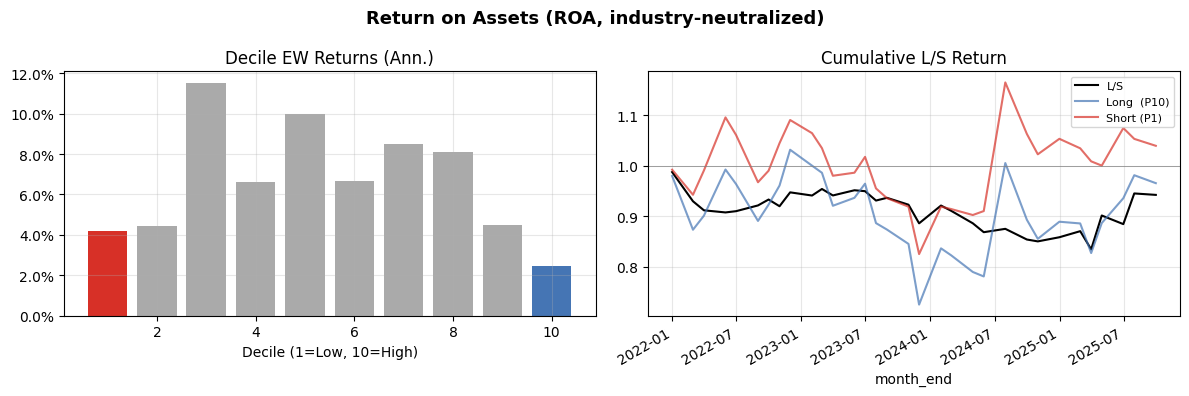

In [19]:
plot_factor("Return on Assets (ROA, industry-neutralized)", dec_roa, ls_roa, save="figures/ROA_return.png")

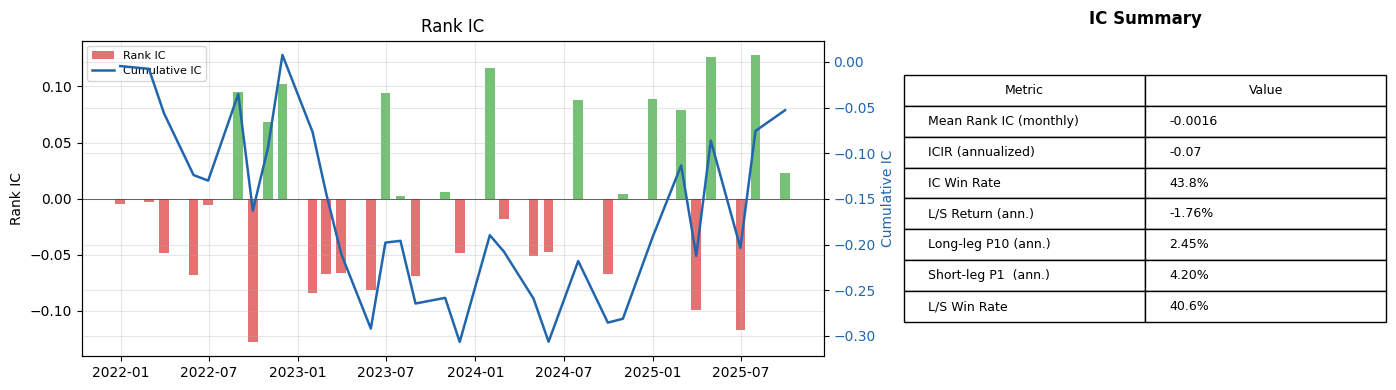

In [20]:
plot_ic_summary(ic_roa, ls_roa, save="figures/ROA_ic.png")

---
## Factor 4: Abnormal Turnover

**Definition:** `monthly_volume_t / mean(monthly_volume_{t-12 : t-1})`

High abnormal turnover indicates excess speculative activity and tends to predict negative future returns (attention/liquidity effect).

In [21]:
at_panel = panel.copy().sort_values(["stock_code", "month_end"])

# 12-month trailing average (shift 1 to avoid using current month)
at_panel["vol_ma12"] = (at_panel.groupby("stock_code")["monthly_volume"]
                         .transform(lambda x: x.shift(1).rolling(12, min_periods=6).mean()))
at_panel["abnormal_turnover"] = at_panel["monthly_volume"] / at_panel["vol_ma12"]

# Remove non-positive values and winsorise top 1%
at_panel = at_panel.dropna(subset=["abnormal_turnover", "next_return"])
upper = at_panel["abnormal_turnover"].quantile(0.99)
at_panel = at_panel[(at_panel["abnormal_turnover"] > 0) &
                     (at_panel["abnormal_turnover"] < upper)]

dec_at = decile_sort(at_panel, "abnormal_turnover")
ic_at  = rank_ic(at_panel, "abnormal_turnover", direction=-1)  # higher turnover → lower return
ls_at  = ls_returns(dec_at, long_high=False)  # Long low-turnover (P1), Short high-turnover (P10)
print(f"Abnormal Turnover: {dec_at.shape[0]:,} obs")

Abnormal Turnover: 7,161 obs


In [22]:
portfolio_table(dec_at)

,EW Return (ann.),VW Return (ann.),EW Vol (ann.),Avg Mkt Cap (B CNY)
Decile,,,,
P1 (Low),23.22%,27.26%,25.38%,0.1
P2,23.74%,12.13%,24.99%,0.2
P3,20.34%,23.80%,26.30%,0.2
P4,8.56%,11.55%,23.56%,0.2
P5,8.64%,3.22%,23.27%,0.2
P6,9.29%,6.49%,20.68%,0.2
P7,3.66%,6.54%,22.13%,0.2
P8,12.29%,-3.38%,23.29%,0.2
P9,6.11%,11.92%,24.79%,0.1


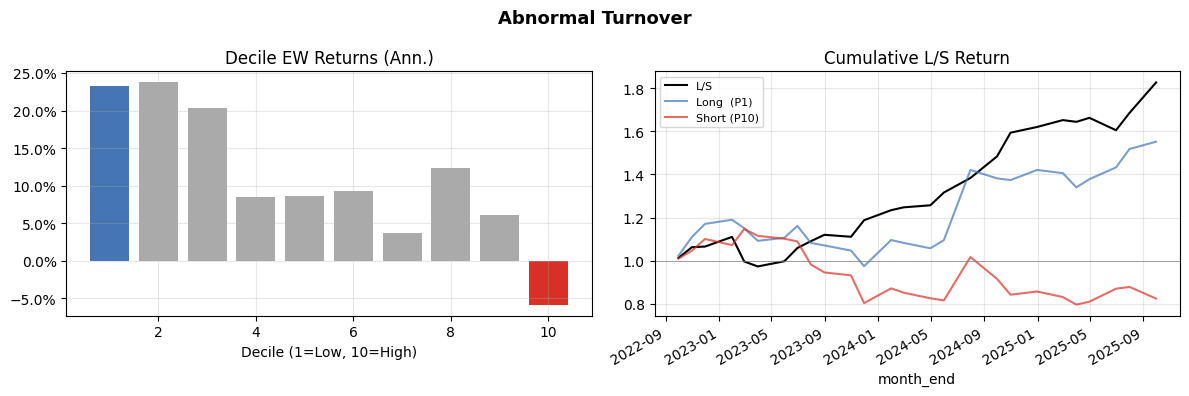

In [23]:
plot_factor("Abnormal Turnover", dec_at, ls_at, long_high=False, save="figures/AT_return.png")

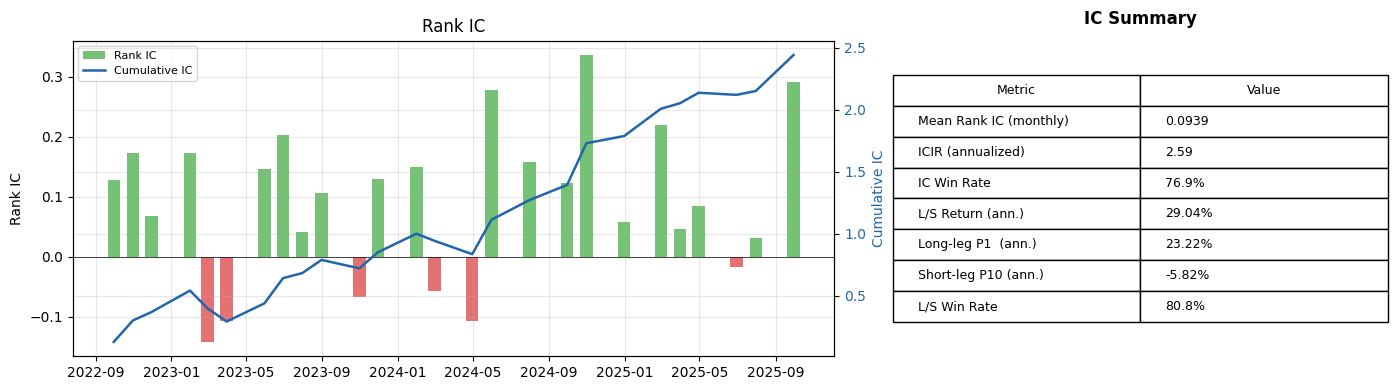

In [ ]:
plot_ic_summary(ic_at, ls_at, long_high=False, save="figures/AT_ic.png")